# Cluster Statistics on Original LUMEN Dataset

This notebook analyzes the labeled original dataset:
- Input: `output/run2/LUMEN_DS_with_clusters_labeled_only.csv`
- Output: summary tables + plots saved under `output/run2/cluster_stats/`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)

In [2]:
DATA_PATH = Path('output/run2/LUMEN_DS_with_clusters_labeled_only.csv')
OUT_DIR = Path('output/run2/cluster_stats')
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH.resolve())

df = pd.read_csv(DATA_PATH, low_memory=False)
df['cluster'] = pd.to_numeric(df['cluster'], errors='coerce').astype('Int64')
df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce')

for col in ['Invoiced price', 'Cost of part', 'GM%', 'Invoiced qty (shipped)', 'Ordered qty', 'max_posterior']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['margin_value'] = df['Invoiced price'] - df['Cost of part']

print('Rows:', len(df))
print('Clusters:', sorted(df['cluster'].dropna().unique().tolist()))
print('Unique customers:', int(df['CustomerID'].nunique(dropna=True)))

Rows: 974962
Clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Unique customers: 1544


## 1) Core cluster-level statistics

In [3]:
cluster_overview = (
    df.groupby('cluster', dropna=False)
      .agg(
          row_count=('cluster', 'size'),
          unique_customers=('CustomerID', pd.Series.nunique),
          total_revenue=('Invoiced price', 'sum'),
          total_cost=('Cost of part', 'sum'),
          total_margin=('margin_value', 'sum'),
          avg_gm_percent=('GM%', 'mean'),
          median_gm_percent=('GM%', 'median'),
          avg_max_posterior=('max_posterior', 'mean'),
          ambiguous_rate=('ambiguous', lambda s: pd.to_numeric(s, errors='coerce').mean()),
      )
      .reset_index()
)

cluster_overview['row_share'] = cluster_overview['row_count'] / cluster_overview['row_count'].sum()
cluster_overview['revenue_share'] = cluster_overview['total_revenue'] / cluster_overview['total_revenue'].sum()
cluster_overview['margin_share'] = cluster_overview['total_margin'] / cluster_overview['total_margin'].sum()

cluster_overview = cluster_overview.sort_values('cluster').reset_index(drop=True)
cluster_overview.to_csv(OUT_DIR / 'cluster_overview.csv', index=False)
cluster_overview

,cluster,row_count,unique_customers,total_revenue,total_cost,total_margin,avg_gm_percent,median_gm_percent,avg_max_posterior,ambiguous_rate,row_share,revenue_share,margin_share
0,0,143475,191,1.490958e+06,1.031414e+06,4.595440e+05,0.011189,0.266552,0.999529,0.0,0.14716,0.001253,0.000403
1,1,15839,98,5.785538e+06,1.313087e+06,4.458664e+06,0.199875,0.385283,0.999989,0.0,0.016246,0.004860,0.003910
2,2,145467,547,1.099053e+09,4.437414e+06,1.094490e+09,0.447510,0.524838,0.999663,0.0,0.149203,0.923306,0.959775
3,3,86230,240,2.245183e+07,1.102158e+07,1.090033e+07,-115.720562,1.000000,0.996428,0.0,0.088444,0.018862,0.009559
4,4,132710,136,9.873542e+06,5.353859e+06,4.519682e+06,0.392860,0.372703,0.999971,0.0,0.136118,0.008295,0.003963
5,5,279409,81,2.247604e+06,-1.716454e+06,3.964059e+06,-0.054971,0.223182,0.999753,0.0,0.286585,0.001888,0.003476
6,6,47406,18,1.985874e+07,1.292348e+07,6.932670e+06,0.186318,0.238723,1.000000,0.0,0.048623,0.016683,0.006079
7,7,10600,12,1.622562e+07,8.047125e+06,8.178491e+06,0.670300,1.000000,1.000000,0.0,0.010872,0.013631,0.007172
8,8,36973,82,3.787889e+06,1.550362e+06,2.237527e+06,0.336670,0.478934,1.000000,0.0,0.037923,0.003182,0.001962
9,9,76853,139,9.570780e+06,5.349847e+06,4.220202e+06,0.212298,0.388690,0.999949,0.0,0.078827,0.008040,0.003701


## 2) Numeric metric profile per cluster

In [4]:
metrics = [
    'Invoiced qty (shipped)',
    'Ordered qty',
    'Invoiced price',
    'Invoiced price (TX)',
    'Cost of part',
    'Material cost of part',
    'Labor cost of part',
    'Overhead cost of part',
    'GM%',
    '# of unique products on a quote',
    'max_posterior',
]
metrics = [m for m in metrics if m in df.columns]

numeric_profile = (
    df.groupby('cluster')[metrics]
      .agg(['mean', 'median'])
)

numeric_profile.columns = [f'{m}_{stat}' for m, stat in numeric_profile.columns]
numeric_profile = numeric_profile.reset_index()
numeric_profile.to_csv(OUT_DIR / 'cluster_numeric_profile.csv', index=False)
numeric_profile.head()

,cluster,Invoiced qty (shipped)_mean,Invoiced qty (shipped)_median,Ordered qty_mean,Ordered qty_median,Invoiced price_mean,Invoiced price_median,Invoiced price (TX)_mean,Invoiced price (TX)_median,Cost of part_mean,Cost of part_median,Material cost of part_mean,Material cost of part_median,Labor cost of part_mean,Labor cost of part_median,Overhead cost of part_mean,Overhead cost of part_median,GM%_mean,GM%_median,# of unique products on a quote_mean,# of unique products on a quote_median,max_posterior_mean,max_posterior_median
0,0,1284.693013,81.000,20656.946439,100.0,10.391763,1.7000,10.391763,1.7000,7.188807,1.2822,4.281131,1.6125,1.134176,0.2486,1.328280,0.3819,0.011189,0.266552,2.184459,1.0,0.999529,1.0
1,1,1780.267936,59.622,3352.557464,272.0,365.271700,5.7000,426.594401,5.8000,89.710135,5.0000,74.706491,4.1528,15.420935,0.0000,16.144762,0.0000,0.199875,0.385283,1.736452,1.0,0.999989,1.0
2,2,7346.583301,262.000,17992.488080,600.0,7555.342465,0.1762,7560.131418,0.1780,30.580711,0.0392,27.416613,0.0290,3.177281,0.0000,6.137718,0.0000,0.447510,0.524838,0.955196,0.0,0.999663,1.0
3,3,3403.875940,191.500,36728.627534,500.0,260.371419,5.6000,298.365266,6.2400,129.155152,0.0000,25.859471,0.0000,3.996194,0.0000,7.214429,0.0000,-115.720562,1.000000,3.907108,1.0,0.996428,1.0
4,4,6067.951062,100.000,14875.072333,1000.0,74.399380,0.1508,111.545000,0.1764,40.342546,0.0668,25.129319,0.0422,0.163831,0.0000,0.266393,0.0000,0.392860,0.372703,4.659633,1.0,0.999971,1.0


## 3) Graphs

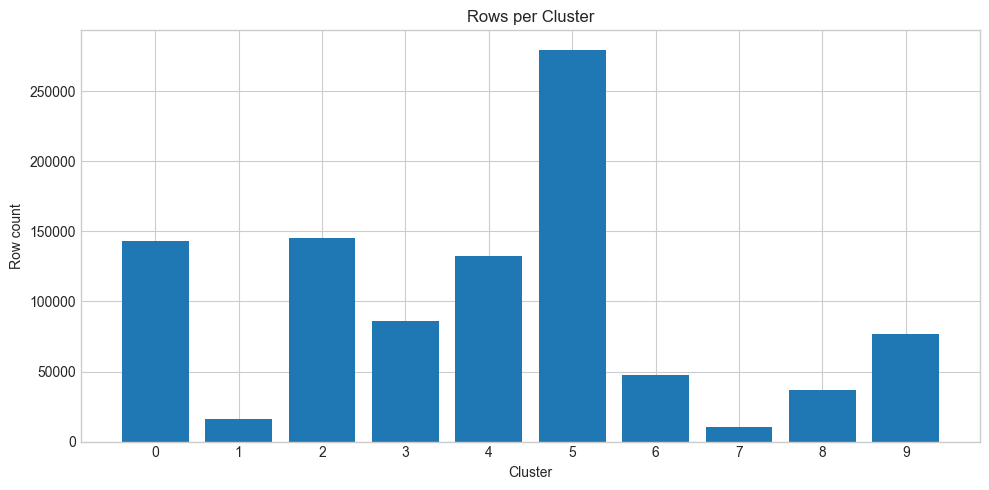

In [5]:
# Cluster size distribution
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = cluster_overview.sort_values('cluster')
ax.bar(plot_df['cluster'].astype(str), plot_df['row_count'])
ax.set_title('Rows per Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Row count')
plt.tight_layout()
fig.savefig(OUT_DIR / 'cluster_row_counts.png', dpi=150)
plt.show()

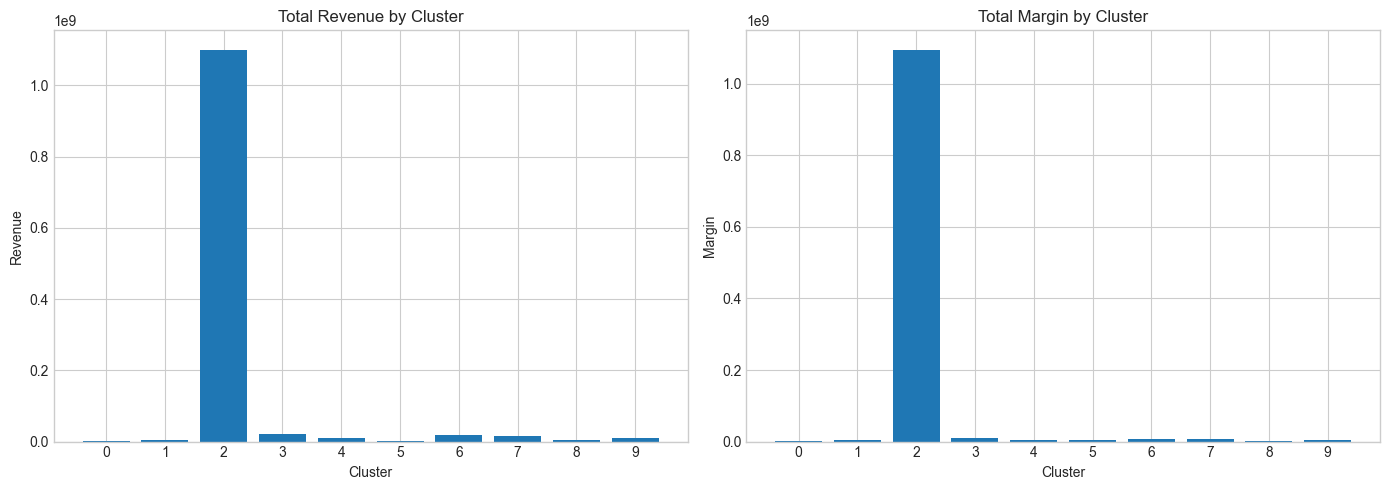

In [6]:
# Revenue and margin by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = cluster_overview.sort_values('cluster')

axes[0].bar(plot_df['cluster'].astype(str), plot_df['total_revenue'])
axes[0].set_title('Total Revenue by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Revenue')

axes[1].bar(plot_df['cluster'].astype(str), plot_df['total_margin'])
axes[1].set_title('Total Margin by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Margin')

plt.tight_layout()
fig.savefig(OUT_DIR / 'cluster_revenue_margin.png', dpi=150)
plt.show()

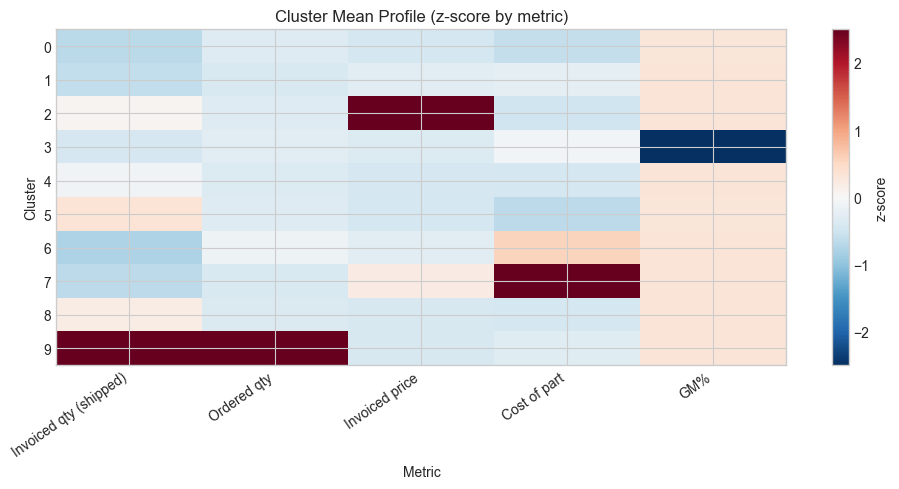

In [7]:
# Heatmap of standardized cluster means for selected metrics
heat_metrics = ['Invoiced qty (shipped)', 'Ordered qty', 'Invoiced price', 'Cost of part', 'GM%']
heat_metrics = [m for m in heat_metrics if m in df.columns]

heat = df.groupby('cluster')[heat_metrics].mean().sort_index()
heat_z = (heat - heat.mean(axis=0)) / heat.std(axis=0).replace(0, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat_z.to_numpy(), aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5)
ax.set_yticks(np.arange(len(heat_z.index)))
ax.set_yticklabels(heat_z.index.astype(str))
ax.set_xticks(np.arange(len(heat_z.columns)))
ax.set_xticklabels(heat_z.columns, rotation=35, ha='right')
ax.set_title('Cluster Mean Profile (z-score by metric)')
ax.set_xlabel('Metric')
ax.set_ylabel('Cluster')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('z-score')
plt.tight_layout()
fig.savefig(OUT_DIR / 'cluster_metric_heatmap.png', dpi=150)
plt.show()

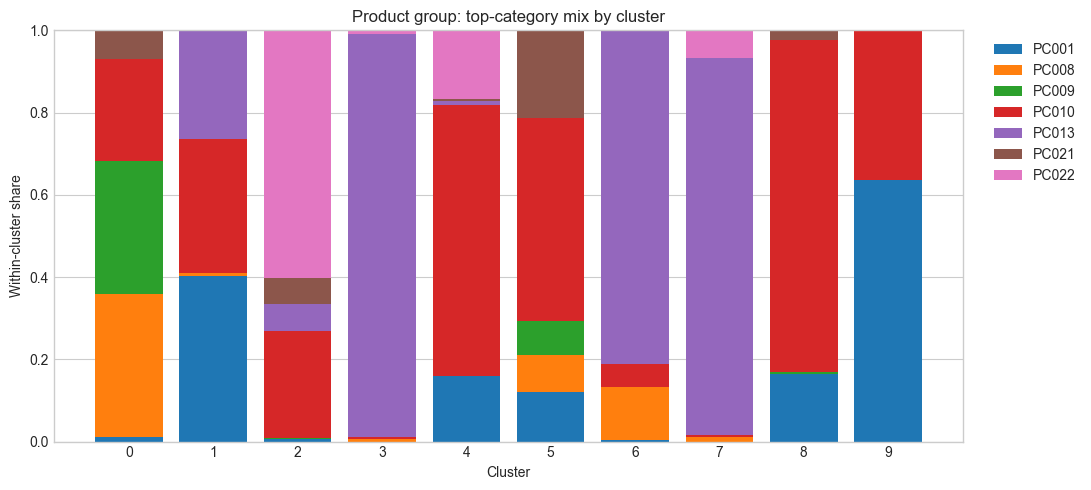

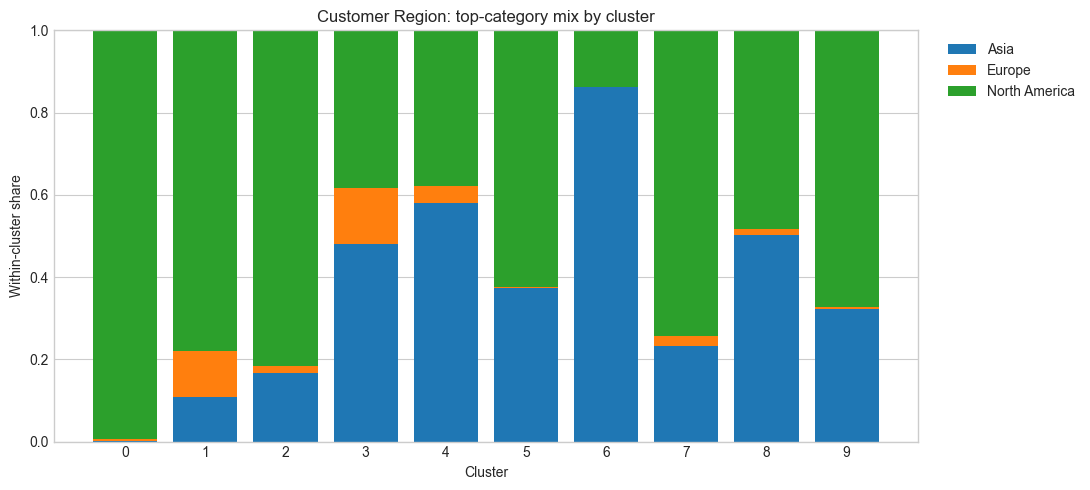

In [8]:
# Top category mix by cluster (Product group and Customer Region if available)
for cat_col in ['Product group', 'Customer Region']:
    if cat_col not in df.columns:
        continue

    top_vals = df[cat_col].value_counts(dropna=False).head(8).index
    work = df[df[cat_col].isin(top_vals)].copy()

    ct = pd.crosstab(work['cluster'], work[cat_col], normalize='index')
    ct = ct.sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(len(ct))
    x = np.arange(len(ct))

    for col in ct.columns:
        vals = ct[col].to_numpy()
        ax.bar(x, vals, bottom=bottom, label=str(col))
        bottom = bottom + vals

    ax.set_xticks(x)
    ax.set_xticklabels(ct.index.astype(str))
    ax.set_ylim(0, 1)
    ax.set_title(f'{cat_col}: top-category mix by cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Within-cluster share')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    safe_name = cat_col.lower().replace(' ', '_')
    fig.savefig(OUT_DIR / f'cluster_mix_{safe_name}.png', dpi=150)
    plt.show()

Saved: C:\Users\dijan\LUMEN2026\classic_methods\output\run2\cluster_stats\monthly_cluster_trends.csv


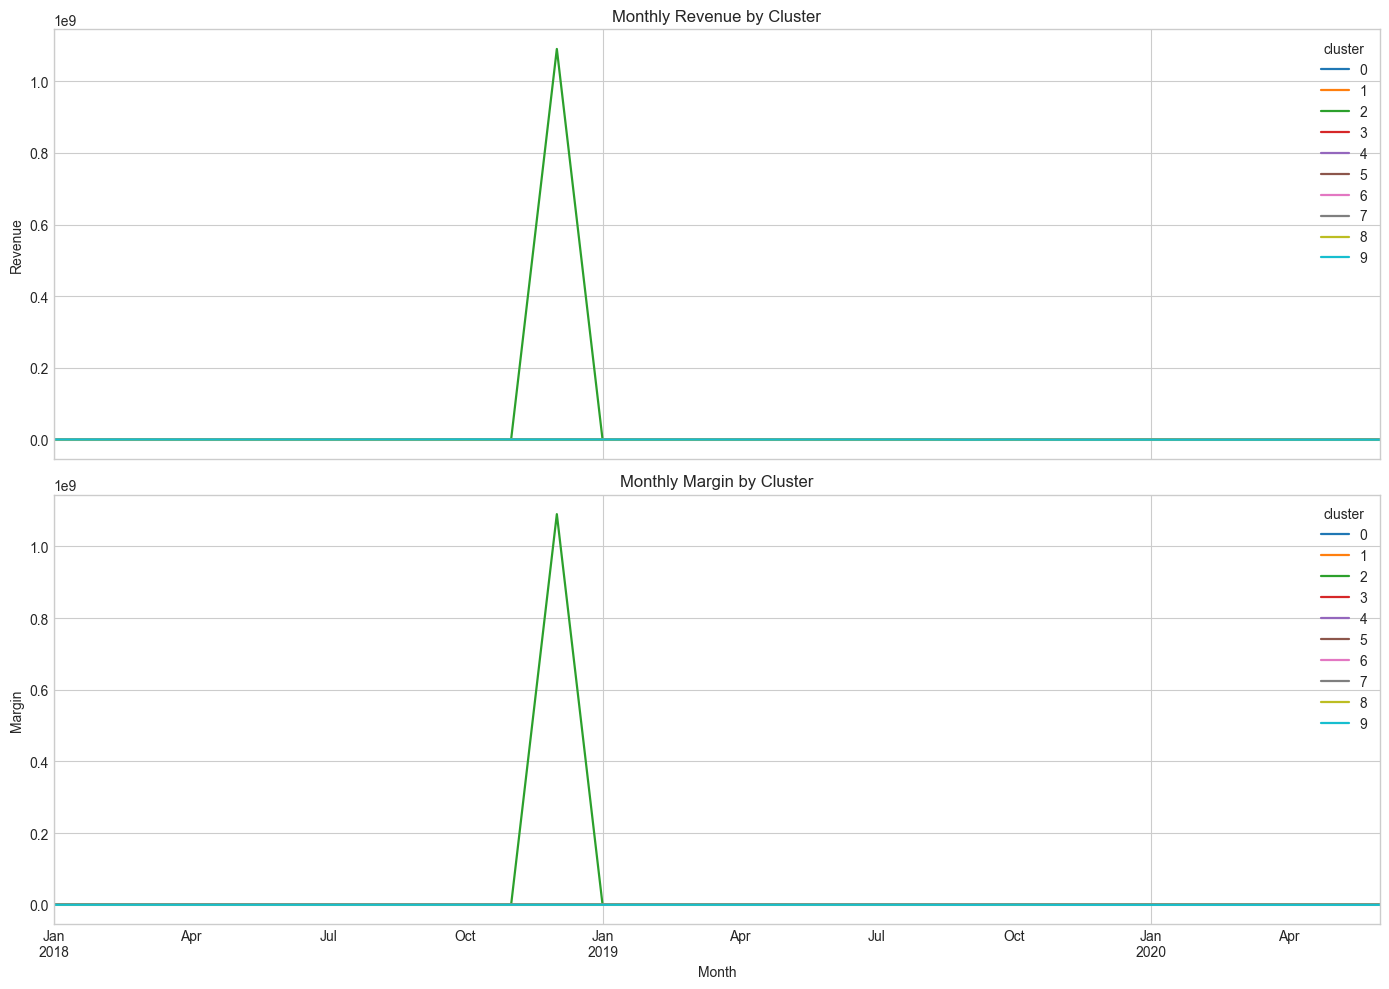

In [9]:
if 'Invoice Date' in df.columns:
    tmp = df.copy()
    tmp['Invoice Date'] = pd.to_datetime(tmp['Invoice Date'], errors='coerce')
    tmp = tmp[tmp['Invoice Date'].notna()].copy()
    tmp['invoice_month'] = tmp['Invoice Date'].dt.to_period('M').dt.to_timestamp()

    monthly = (
        tmp.groupby(['invoice_month', 'cluster'], dropna=False)
           .agg(
               revenue=('Invoiced price', 'sum'),
               margin=('margin_value', 'sum'),
               rows=('cluster', 'size'),
           )
           .reset_index()
           .sort_values(['invoice_month', 'cluster'])
    )
    monthly.to_csv(OUT_DIR / 'monthly_cluster_trends.csv', index=False)
    print('Saved:', (OUT_DIR / 'monthly_cluster_trends.csv').resolve())

    revenue_pivot = monthly.pivot(index='invoice_month', columns='cluster', values='revenue').fillna(0.0)
    margin_pivot = monthly.pivot(index='invoice_month', columns='cluster', values='margin').fillna(0.0)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    revenue_pivot.plot(ax=axes[0], linewidth=1.6)
    axes[0].set_title('Monthly Revenue by Cluster')
    axes[0].set_ylabel('Revenue')

    margin_pivot.plot(ax=axes[1], linewidth=1.6)
    axes[1].set_title('Monthly Margin by Cluster')
    axes[1].set_ylabel('Margin')
    axes[1].set_xlabel('Month')

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'monthly_revenue_margin_by_cluster.png', dpi=150)
    plt.show()
else:
    print('Column Invoice Date not found.')

## 7) Monthly revenue and margin trends by cluster

In [10]:
if 'Product group' in df.columns:
    top_product_groups = (
        df.groupby(['cluster', 'Product group'], dropna=False)
          .agg(
              row_count=('Product group', 'size'),
              total_revenue=('Invoiced price', 'sum'),
              total_margin=('margin_value', 'sum'),
          )
          .reset_index()
          .sort_values(['cluster', 'total_revenue'], ascending=[True, False])
    )

    top10_product_groups = top_product_groups.groupby('cluster', group_keys=False).head(10).reset_index(drop=True)
    top10_product_groups.to_csv(OUT_DIR / 'top10_product_groups_per_cluster.csv', index=False)
    print('Saved:', (OUT_DIR / 'top10_product_groups_per_cluster.csv').resolve())
    display(top10_product_groups.head(40))
else:
    print('Column Product group not found.')

Saved: C:\Users\dijan\LUMEN2026\classic_methods\output\run2\cluster_stats\top10_product_groups_per_cluster.csv


,cluster,Product group,row_count,total_revenue,total_margin
0,0,NaN,12496,5.763893e+05,3.035384e+05
1,0,PC008,40499,2.820518e+05,9.714577e+04
2,0,PC023,10327,2.010781e+05,-1.874780e+04
3,0,PC009,37453,1.723152e+05,4.292807e+04
4,0,PC010,28782,1.274994e+05,6.241670e+03
5,0,PC001,1164,4.702739e+04,6.373245e+03
6,0,PC021,7937,4.424739e+04,9.524010e+03
7,0,PC015,3491,3.481195e+04,1.317626e+04
8,0,PC025,526,3.017516e+03,-6.731653e+02
9,0,PC020,741,2.399934e+03,5.108840e+01


## 6) Top product groups by cluster

In [11]:
top_customers = (
    df.groupby(['cluster', 'CustomerID'], dropna=False)
      .agg(
          row_count=('CustomerID', 'size'),
          total_revenue=('Invoiced price', 'sum'),
          total_margin=('margin_value', 'sum'),
      )
      .reset_index()
      .sort_values(['cluster', 'total_revenue'], ascending=[True, False])
)

top20_customers = top_customers.groupby('cluster', group_keys=False).head(20).reset_index(drop=True)
top20_customers.to_csv(OUT_DIR / 'top20_customers_per_cluster.csv', index=False)

print('Saved:', (OUT_DIR / 'top20_customers_per_cluster.csv').resolve())
top20_customers.head(30)

Saved: C:\Users\dijan\LUMEN2026\classic_methods\output\run2\cluster_stats\top20_customers_per_cluster.csv


,cluster,CustomerID,row_count,total_revenue,total_margin
0,0,35108,1276,1.758824e+05,8.200566e+03
1,0,18833,104,1.023684e+05,3.047261e+04
2,0,270478,9975,1.004541e+05,3.639664e+04
3,0,17912,4629,9.268489e+04,-1.218299e+04
4,0,422,3610,7.068246e+04,5.532751e+04
5,0,1894,664,6.750888e+04,6.604142e+04
6,0,1989,866,6.149383e+04,5.735780e+04
7,0,17920,4124,5.860466e+04,-6.156725e+03
8,0,17914,7220,5.703734e+04,-3.755902e+03
9,0,270538,9204,4.738390e+04,1.712699e+04


## 5) Top customers by revenue in each cluster

## 4) Export recap

Saved artifacts:
- `cluster_overview.csv`
- `cluster_numeric_profile.csv`
- `cluster_row_counts.png`
- `cluster_revenue_margin.png`
- `cluster_metric_heatmap.png`
- `cluster_mix_product_group.png` (if column exists)
- `cluster_mix_customer_region.png` (if column exists)